# Credit-risk behavioural scoring: model training and evaluation

**Question:** given a credit-card customer's last six months of billing and payment history,
will they miss their next payment?

This is a behavioural scorecard. The customer already holds the card, so the model re-scores
them every month as new repayment history arrives. That is how banks manage a live portfolio:
limits, interventions and collections priority are all decided from behaviour after
origination, not from the original application. Repayment history is the signal this task is
built on, which is why "PAY_1" to "PAY_6" and the features derived from them sit at the centre
of the model.

**Data:** UCI *Default of Credit Card Clients* (Yeh & Lien, 2009). 30,000 Taiwanese card
customers, April to September 2005.

**Protocol.** Hyperparameters come from 5-fold cross-validation on the train split. The
validation split is used to pick the model family, the calibrator and the threshold.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SEED = 42
TARGET = "default_next_month"
PROTECTED = ["SEX", "AGE", "EDUCATION", "MARRIAGE"]
PAY_COLS = [f"PAY_{i}" for i in range(1, 7)]
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
AMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
ARTIFACTS = PROJECT_ROOT / "backend" / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\User\Documents\UNI\credit_risk_system


## 1. Load and clean

"EDUCATION" and "MARRIAGE" hold a few category codes that the UCI dataset page never
documents. The page lists "EDUCATION" as 1 graduate school, 2 university, 3 high school,
4 other, but the file also contains 0, 5 and 6. It lists "MARRIAGE" as 1 married, 2 single,
3 other, but the file also contains 0. Those undocumented codes are merged into "other",
which keeps the affected customers in the sample instead of dropping their rows.

"PAY_0" is renamed "PAY_1" so the six payment-status columns run in order.

In [2]:
def load_taiwan() -> pd.DataFrame:
    csv_path = PROJECT_ROOT / "data" / "raw" / "taiwan_credit.csv"
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Place the UCI dataset at {csv_path}. "
            "Source: https://archive.ics.uci.edu/dataset/350/"
        )

    df = pd.read_csv(csv_path)

    # Fold undocumented category codes into the documented 'other' level.
    df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})
    return df


raw = load_taiwan()
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Missing values: {int(raw.isna().sum().sum())}")
raw.head()

Shape: 30,000 rows x 24 columns
Missing values: 0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
target_balance = pd.DataFrame({
    "count": raw[TARGET].value_counts().sort_index(),
    "percentage": raw[TARGET].value_counts(normalize=True).sort_index() * 100,
}).rename(index={0: "no default next month", 1: "default next month"})
target_balance

,count,percentage
default_next_month,,
no default next month,23364,77.8800
default next month,6636,22.1200


In [4]:
SEX_LABELS = {1: "male", 2: "female"}
EDUCATION_LABELS = {1: "graduate school", 2: "university", 3: "high school", 4: "other"}
MARRIAGE_LABELS = {1: "married", 2: "single", 3: "other"}
AGE_BANDS = [20, 30, 40, 50, 60, 100]
AGE_LABELS = ["21-30", "31-40", "41-50", "51-60", "60+"]

profile = []
for column, labels in [("SEX", SEX_LABELS), ("EDUCATION", EDUCATION_LABELS),
                       ("MARRIAGE", MARRIAGE_LABELS)]:
    grouped = raw.groupby(column)[TARGET].agg(["count", "mean"])
    grouped.index = grouped.index.map(lambda v: f"{column}={labels.get(v, v)}")
    profile.append(grouped)

age_bands = pd.cut(raw["AGE"], AGE_BANDS, labels=AGE_LABELS)
age_grouped = raw.groupby(age_bands, observed=True)[TARGET].agg(["count", "mean"])
age_grouped.index = age_grouped.index.map(lambda v: f"AGE={v}")
profile.append(age_grouped)

pd.concat(profile).rename(columns={"mean": "default_rate"})

,count,default_rate
SEX=male,11888,0.2417
SEX=female,18112,0.2078
EDUCATION=graduate school,10585,0.1923
EDUCATION=university,14030,0.2373
EDUCATION=high school,4917,0.2516
EDUCATION=other,468,0.0705
MARRIAGE=married,13659,0.2347
MARRIAGE=single,15964,0.2093
MARRIAGE=other,377,0.2361
AGE=21-30,11013,0.2244


## 2. Feature engineering

Most of the 23 raw columns are six-month sequences. Trees can read them, but they hide the
patterns an analyst would look for. The engineered features turn those sequences into numbers
with a plain business meaning:

- **Delinquency**: how late, how often, and whether it is getting worse.
- **Utilisation**: balance as a share of the credit limit, monthly and summarised. High and
  rising utilisation is a classic warning sign.
- **Repayment**: how much of last month's bill the customer actually paid. Paying the minimum
  every month is very different from clearing the balance.

Each feature uses only that customer's own row, so nothing is fitted on the population and
nothing can leak between splits.

In [5]:
def engineer(df: pd.DataFrame) -> pd.DataFrame:
    out = df.drop(columns=[TARGET]).copy()
    limit = out["LIMIT_BAL"].replace(0, np.nan)

    # delinquency profile across the six observed months
    pay = out[PAY_COLS]
    out["pay_max"] = pay.max(axis=1)
    out["pay_mean"] = pay.mean(axis=1)
    out["pay_months_late"] = (pay > 0).sum(axis=1)
    out["pay_months_revolving"] = (pay == 0).sum(axis=1)
    out["pay_trend"] = out["PAY_1"] - out["PAY_6"]
    out["pay_worsening"] = (pay.diff(axis=1).iloc[:, 1:] > 0).sum(axis=1)

    # credit utilisation
    for i, column in enumerate(BILL_COLS, start=1):
        out[f"util_{i}"] = out[column] / limit
    util = out[[f"util_{i}" for i in range(1, 7)]]
    out["util_mean"] = util.mean(axis=1)
    out["util_max"] = util.max(axis=1)
    out["util_trend"] = out["util_1"] - out["util_6"]
    out["remaining_credit"] = out["LIMIT_BAL"] - out["BILL_AMT1"]

    # repayment behaviour
    for i in range(1, 6):
        prior_bill = out[f"BILL_AMT{i + 1}"].where(out[f"BILL_AMT{i + 1}"] > 0)
        out[f"repay_ratio_{i}"] = out[f"PAY_AMT{i}"] / prior_bill
    repay = out[[f"repay_ratio_{i}" for i in range(1, 6)]]
    out["repay_ratio_mean"] = repay.mean(axis=1)
    out["repay_ratio_min"] = repay.min(axis=1)
    out["months_zero_payment"] = (out[AMT_COLS] == 0).sum(axis=1)

    out["bill_mean"] = out[BILL_COLS].mean(axis=1)
    out["pay_amt_mean"] = out[AMT_COLS].mean(axis=1)
    out["pay_to_bill_gap"] = out["bill_mean"] - out["pay_amt_mean"]

    return out.replace([np.inf, -np.inf], np.nan)


X_all = engineer(raw)
y_all = raw[TARGET].astype("int8")
audit_all = raw[PROTECTED].copy()

print(f"Raw features:        {raw.shape[1] - 1}")
print(f"Engineered features: {X_all.shape[1]}")
X_all.head()

Raw features:        23
Engineered features: 50


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,pay_max,pay_mean,pay_months_late,pay_months_revolving,pay_trend,pay_worsening,util_1,util_2,util_3,util_4,util_5,util_6,util_mean,util_max,util_trend,remaining_credit,repay_ratio_1,repay_ratio_2,repay_ratio_3,repay_ratio_4,repay_ratio_5,repay_ratio_mean,repay_ratio_min,months_zero_payment,bill_mean,pay_amt_mean,pay_to_bill_gap
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,2,-0.3333,2,0,4,0,0.1956,0.1551,0.0345,0.0000,0.0000,0.0000,0.0642,0.1956,0.1956,16087,0.0000,1.0000,NaN,NaN,NaN,0.5000,0.0000,5,"1,284.0000",114.8333,"1,169.1667"
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,2,0.5000,2,3,-3,2,0.0223,0.0144,0.0223,0.0273,0.0288,0.0272,0.0237,0.0288,-0.0048,117318,0.0000,0.3729,0.3056,0.2894,0.0000,0.1936,0.0000,2,"2,846.1667",833.3333,"2,012.8333"
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,0.0000,0,6,0,0,0.3249,0.1559,0.1507,0.1592,0.1661,0.1728,0.1882,0.3249,0.1521,60761,0.1082,0.1106,0.0698,0.0669,0.0643,0.0840,0.0643,0,"16,942.1667","1,836.3333","15,105.8333"
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,0.0000,0,6,0,0,0.9398,0.9647,0.9858,0.5663,0.5792,0.5909,0.7711,0.9858,0.3489,3010,0.0415,0.0410,0.0424,0.0380,0.0362,0.0398,0.0362,0,"38,555.6667","1,398.0000","37,157.6667"
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,-0.3333,0,4,-1,2,0.1723,0.1134,0.7167,0.4188,0.3829,0.3826,0.3645,0.7167,-0.2103,41383,0.3527,1.0236,0.4776,0.4701,0.0360,0.4720,0.0360,0,"18,223.1667","9,841.5000","8,381.6667"


### Splits and the fairness-blind feature set

The protected attributes ("SEX", "AGE", "EDUCATION", "MARRIAGE") are dropped from the model
inputs and kept only for the audit. This is *fairness through unawareness*. It is the weakest
form of fairness, because proxies survive, but it is the baseline the system's governance rules
ask for.

Splits are stratified 70/15/15. There is no origination date to split on, since every customer
is observed over the same six months, so a random stratified split is the right choice.

In [6]:
X_blind = X_all.drop(columns=PROTECTED)

idx_train, idx_rest = train_test_split(
    X_all.index, test_size=0.30, stratify=y_all, random_state=SEED
)
idx_validation, idx_test = train_test_split(
    idx_rest, test_size=0.50, stratify=y_all.loc[idx_rest], random_state=SEED
)

X, y, audit = {}, {}, {}
for name, index in [("train", idx_train), ("validation", idx_validation), ("test", idx_test)]:
    X[name] = X_blind.loc[index]
    y[name] = y_all.loc[index]
    audit[name] = audit_all.loc[index]

pd.DataFrame({
    name: {
        "rows": len(X[name]),
        "features": X[name].shape[1],
        "default_rate": y[name].mean(),
        "defaults": int(y[name].sum()),
    }
    for name in ("train", "validation", "test")
}).T

,rows,features,default_rate,defaults
train,"21,000.0000",46.0000,0.2212,"4,645.0000"
validation,"4,500.0000",46.0000,0.2211,995.0000
test,"4,500.0000",46.0000,0.2213,996.0000


## 3. Evaluation metrics

Five measures are reported throughout.

| Metric | What it measures | Why it is here |
| --- | --- | --- |
| **ROC-AUC / Gini** | Ranking quality, no threshold needed | Main selection metric; unaffected by class balance |
| **KS statistic** | Biggest gap between the two score distributions | Standard for scorecards |
| **PR-AUC** | Precision and recall on the minority class | The view ROC hides when defaults are rare |
| **Brier score** | Error of the predicted probabilities | Whether the probabilities can be trusted |
| **Precision / recall / F1** | Quality of the decision at a cut-off | The operating point the business uses |

ROC-AUC is the selection metric because class balance does not affect it, so the 22% default
rate does not distort the comparison.

In [7]:
def ks_statistic(y_true, scores) -> float:
    fpr, tpr, _ = roc_curve(y_true, scores)
    return float(np.max(tpr - fpr))


def evaluate(y_true, scores, threshold=None) -> dict:
    y_true = np.asarray(y_true)
    metrics = {
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "ks": ks_statistic(y_true, scores),
        "brier": brier_score_loss(y_true, np.clip(scores, 0, 1)),
    }
    metrics["gini"] = 2 * metrics["roc_auc"] - 1
    if threshold is not None:
        predicted = (scores >= threshold).astype(int)
        metrics |= {
            "threshold": threshold,
            "f1": f1_score(y_true, predicted),
            "precision": precision_score(y_true, predicted, zero_division=0),
            "recall": recall_score(y_true, predicted),
        }
    return metrics


def leaderboard(results: dict, sort="roc_auc") -> pd.DataFrame:
    return pd.DataFrame(results).T.sort_values(sort, ascending=False)

## 4. Model comparison

Nine families in four groups:

- **Linear / probabilistic**: logistic regression, LDA, Gaussian naive Bayes. Interpretable,
  fast, and the regulatory default in credit scoring.
- **Bagged trees**: random forest, extra trees. Robust to outliers.
- **Boosted trees**: HistGradientBoosting, LightGBM, XGBoost. Usually the best on tabular data.
- **Neural**: a small MLP, included because the literature review covers deep learning.

Each model sits in a pipeline whose imputer and scaler are fitted on train only, so validation
stays unseen.

In [8]:
def sk_pipeline(model, scale: bool) -> Pipeline:
    steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    return Pipeline(steps + [("model", model)])


zoo = {
    "LogisticRegression": sk_pipeline(LogisticRegression(max_iter=3000), True),
    "LDA": sk_pipeline(LinearDiscriminantAnalysis(), True),
    "GaussianNB": sk_pipeline(GaussianNB(), True),
    "MLP": sk_pipeline(
        MLPClassifier((64, 32), alpha=1e-3, max_iter=80, early_stopping=True,
                      random_state=SEED), True),
    "RandomForest": sk_pipeline(
        RandomForestClassifier(n_estimators=600, min_samples_leaf=5, n_jobs=-1,
                               random_state=SEED), False),
    "ExtraTrees": sk_pipeline(
        ExtraTreesClassifier(n_estimators=600, min_samples_leaf=5, n_jobs=-1,
                             random_state=SEED), False),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=500, learning_rate=0.05, l2_regularization=1.0,
        early_stopping=False, random_state=SEED),
    "LightGBM": LGBMClassifier(
        n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=50,
        subsample=0.9, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
        n_jobs=-1, random_state=SEED, verbose=-1),
    "XGBoost": XGBClassifier(
        n_estimators=600, learning_rate=0.03, max_depth=5, min_child_weight=5,
        subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0, tree_method="hist",
        eval_metric="auc", n_jobs=-1, random_state=SEED),
}

baseline_results, baseline_scores = {}, {}
for name, model in zoo.items():
    model.fit(X["train"], y["train"])
    scores = model.predict_proba(X["validation"])[:, 1]
    baseline_scores[name] = scores
    baseline_results[name] = evaluate(y["validation"], scores)
    print(f"  fitted {name}")

baseline_table = leaderboard(baseline_results)
baseline_table[["roc_auc", "gini", "ks", "pr_auc", "brier"]]

  fitted LogisticRegression


  fitted LDA
  fitted GaussianNB


  fitted MLP


  fitted RandomForest


  fitted ExtraTrees


  fitted HistGradientBoosting


  fitted LightGBM


  fitted XGBoost


,roc_auc,gini,ks,pr_auc,brier
XGBoost,0.7747,0.5493,0.4253,0.5456,0.1371
LightGBM,0.7723,0.5445,0.4222,0.5443,0.1377
ExtraTrees,0.7721,0.5441,0.4249,0.5528,0.1364
MLP,0.7716,0.5432,0.4202,0.5487,0.1367
RandomForest,0.7709,0.5418,0.4217,0.5468,0.1373
HistGradientBoosting,0.7687,0.5374,0.4125,0.5408,0.1385
LogisticRegression,0.7604,0.5207,0.4011,0.5165,0.1405
LDA,0.7573,0.5147,0.3981,0.5164,0.1437
GaussianNB,0.7363,0.4727,0.3941,0.4907,0.6238


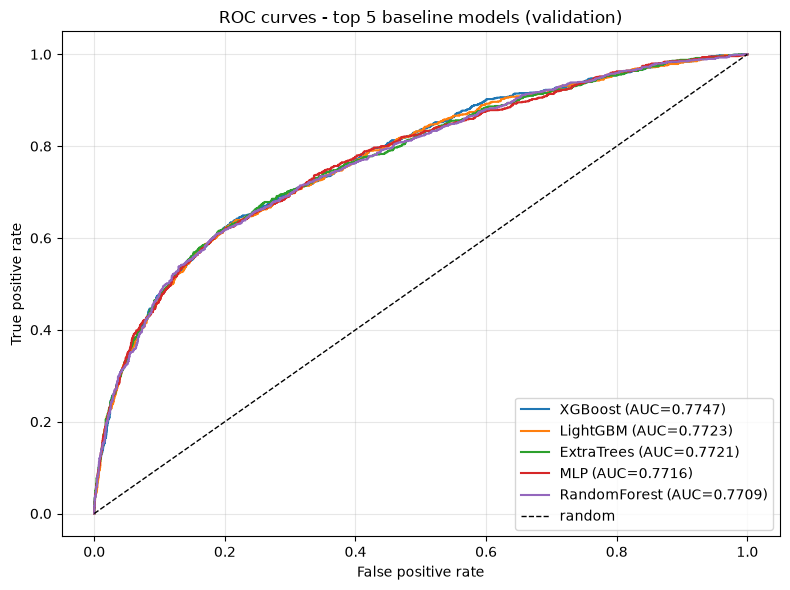

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in baseline_table.index[:5]:
    fpr, tpr, _ = roc_curve(y["validation"], baseline_scores[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={baseline_table.loc[name, 'roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves - top 5 baseline models (validation)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### What fairness through unawareness costs

Refitting the best baseline with the protected attributes added back shows how much accuracy
the governance rule costs. If the gap is tiny there is no accuracy reason to keep them, which
is a useful result in itself.

In [10]:
X_with_protected = {name: X_all.loc[X[name].index] for name in ("train", "validation", "test")}

aware_model = XGBClassifier(
    n_estimators=600, learning_rate=0.03, max_depth=5, min_child_weight=5,
    subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0, tree_method="hist",
    eval_metric="auc", n_jobs=-1, random_state=SEED,
).fit(X_with_protected["train"], y["train"])

with_protected = roc_auc_score(
    y["validation"], aware_model.predict_proba(X_with_protected["validation"])[:, 1]
)
without_protected = baseline_results["XGBoost"]["roc_auc"]

pd.Series({
    "AUC with protected attributes": with_protected,
    "AUC without (deployed model)": without_protected,
    "Accuracy cost of fairness": with_protected - without_protected,
}, name="value").to_frame()

,value
AUC with protected attributes,0.7753
AUC without (deployed model),0.7747
Accuracy cost of fairness,0.0007


## 5. Hyperparameter tuning

Parameters come from a randomized search scored by **5-fold cross-validation on the train
split**, not on validation. With 4,500 validation rows, AUC has a standard error of about
+/-0.01, so tuning against it would mostly fit that split's noise. Cross-validation averages
over five folds and leaves validation free for its real job: picking the family, the calibrator
and the threshold.

The winning settings are written into the cell below.

| Family | Cross-validated AUC |
| --- | --- |
| LightGBM | 0.7917 |
| XGBoost | 0.7905 |

In [11]:
LGBM_BEST = {
    "n_estimators": 166,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "min_child_samples": 50,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0
}

XGB_BEST = {
    "n_estimators": 211,
    "learning_rate": 0.03,
    "max_depth": 5,
    "min_child_weight": 5,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "gamma": 0.0
}

print("LightGBM tuned:", LGBM_BEST)
print()
print("XGBoost tuned:", XGB_BEST)

LightGBM tuned: {'n_estimators': 166, 'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 50, 'subsample': 0.9, 'subsample_freq': 1, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0}

XGBoost tuned: {'n_estimators': 211, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.9, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'gamma': 0.0}


### Seed averaging

Boosted trees vary from run to run because they subsample rows and columns. Averaging three
seeds removes some of that cheaply: the average is never worse than a typical single seed, and
usually a little better.

In [12]:
SEEDS = (42, 202, 777)


def seed_average(builder, fit_X, fit_y, eval_X):
    scores = []
    for seed in SEEDS:
        model = builder(seed)
        model.fit(fit_X, fit_y)
        scores.append(model.predict_proba(eval_X)[:, 1])
    return np.mean(scores, axis=0)


build_lgbm = lambda seed: LGBMClassifier(**LGBM_BEST, n_jobs=-1, random_state=seed, verbose=-1)
build_xgb = lambda seed: XGBClassifier(
    **XGB_BEST, tree_method="hist", eval_metric="auc", n_jobs=-1, random_state=seed
)

tuned_scores = {
    "LightGBM_tuned": seed_average(build_lgbm, X["train"], y["train"], X["validation"]),
    "XGBoost_tuned": seed_average(build_xgb, X["train"], y["train"], X["validation"]),
    "RandomForest": baseline_scores["RandomForest"],
    "LogisticRegression": baseline_scores["LogisticRegression"],
}

tuned_results = {name: evaluate(y["validation"], s) for name, s in tuned_scores.items()}
leaderboard(tuned_results)[["roc_auc", "gini", "ks", "pr_auc", "brier"]]

,roc_auc,gini,ks,pr_auc,brier
XGBoost_tuned,0.7813,0.5626,0.4298,0.5543,0.1355
LightGBM_tuned,0.7802,0.5604,0.4304,0.5563,0.1355
RandomForest,0.7709,0.5418,0.4217,0.5468,0.1373
LogisticRegression,0.7604,0.5207,0.4011,0.5165,0.1405


## 6. Ensembling

Components are blended on the **rank** scale, not the probability scale, so a well-calibrated
model cannot dominate one that ranks well but is badly scaled. A few combinations are compared
and the best on validation goes forward.

In [13]:
def rank_blend(score_map, names, weights=None):
    ranks = np.array([rankdata(score_map[n]) / len(score_map[n]) for n in names])
    weights = np.ones(len(names)) if weights is None else np.asarray(weights, float)
    return np.average(ranks, axis=0, weights=weights)


combos = {
    "LGBM+XGB": (["LightGBM_tuned", "XGBoost_tuned"], None),
    "LGBM+XGB+RF": (["LightGBM_tuned", "XGBoost_tuned", "RandomForest"], None),
    "LGBM+XGB+LR": (["LightGBM_tuned", "XGBoost_tuned", "LogisticRegression"], None),
    "ALL4": (["LightGBM_tuned", "XGBoost_tuned", "RandomForest", "LogisticRegression"], None),
    "ALL4 weighted": (
        ["LightGBM_tuned", "XGBoost_tuned", "RandomForest", "LogisticRegression"],
        [3, 3, 1, 1],
    ),
}

ensemble_results = dict(tuned_results)
ensemble_scores = dict(tuned_scores)
for label, (names, weights) in combos.items():
    blended = rank_blend(tuned_scores, names, weights)
    ensemble_scores[f"blend {label}"] = blended
    ensemble_results[f"blend {label}"] = evaluate(y["validation"], blended)

ensemble_table = leaderboard(ensemble_results)
ensemble_table[["roc_auc", "gini", "ks", "pr_auc"]]

,roc_auc,gini,ks,pr_auc
blend ALL4 weighted,0.7814,0.5627,0.4284,0.5584
XGBoost_tuned,0.7813,0.5626,0.4298,0.5543
blend LGBM+XGB,0.7810,0.5619,0.4303,0.5557
blend ALL4,0.7805,0.5609,0.4253,0.5577
blend LGBM+XGB+LR,0.7804,0.5608,0.4167,0.5560
LightGBM_tuned,0.7802,0.5604,0.4304,0.5563
blend LGBM+XGB+RF,0.7794,0.5588,0.4252,0.5551
RandomForest,0.7709,0.5418,0.4217,0.5468
LogisticRegression,0.7604,0.5207,0.4011,0.5165


In [14]:
CHAMPION = ensemble_table.index[0]
champion_validation = ensemble_scores[CHAMPION]

print(f"Selected on validation ROC-AUC: {CHAMPION}")
print(f"  validation AUC  = {ensemble_table.loc[CHAMPION, 'roc_auc']:.4f}")
print(f"  validation Gini = {ensemble_table.loc[CHAMPION, 'gini']:.4f}")
print(f"  validation KS   = {ensemble_table.loc[CHAMPION, 'ks']:.4f}")

Selected on validation ROC-AUC: blend ALL4 weighted
  validation AUC  = 0.7814
  validation Gini = 0.5627
  validation KS   = 0.4284


## 7. Probability calibration

A rank-blended score is not a probability, it is close to uniform. Even raw boosted-tree
outputs are over-confident near 0 and 1. Real probabilities are needed for three things: the
risk bands the loan officer sees, the customer's right to an explanation, and any expected-loss
figure.

Both calibrators are fitted on **validation**, with test still untouched. Calibration keeps the
ranking identical, so AUC cannot change. Only the Brier score moves.

In [15]:
calibration_comparison = {}
calibrators = {}

platt = LogisticRegression(max_iter=1000)
platt.fit(champion_validation.reshape(-1, 1), y["validation"])
calibrators["sigmoid"] = lambda s: platt.predict_proba(s.reshape(-1, 1))[:, 1]

isotonic = IsotonicRegression(out_of_bounds="clip")
isotonic.fit(champion_validation, y["validation"])
calibrators["isotonic"] = isotonic.predict

for method, fn in calibrators.items():
    calibrated = fn(champion_validation)
    calibration_comparison[method] = {
        "brier": brier_score_loss(y["validation"], np.clip(calibrated, 0, 1)),
        "roc_auc": roc_auc_score(y["validation"], calibrated),
    }

calibration_comparison["uncalibrated"] = {
    "brier": brier_score_loss(y["validation"], np.clip(champion_validation, 0, 1)),
    "roc_auc": roc_auc_score(y["validation"], champion_validation),
}

CALIBRATION_METHOD = min(
    ("sigmoid", "isotonic"), key=lambda m: calibration_comparison[m]["brier"]
)
print(f"Selected calibrator: {CALIBRATION_METHOD}")
pd.DataFrame(calibration_comparison).T

Selected calibrator: isotonic


,brier,roc_auc
sigmoid,0.1387,0.7814
isotonic,0.1335,0.7855
uncalibrated,0.2340,0.7814


## 8. Decision threshold

A score is only useful once a cut-off turns it into an action. Two views are given.

**F1-optimal** treats precision and recall as equally important. The project specification asks
for it, so it is reported.

**Cost-optimal** reflects what the lender actually loses. The two mistakes do not cost the same:
missing a default means losing the outstanding balance, while flagging a customer who would
have paid only loses the interest margin. That ratio is a business decision, not something the
data can tell us, so the table sweeps it from 1:1 to 10:1.

In [16]:
def best_f1_threshold(y_true, scores):
    grid = np.unique(np.quantile(scores, np.linspace(0.01, 0.99, 197)))
    f1s = [f1_score(y_true, (scores >= t).astype(int)) for t in grid]
    best = int(np.argmax(f1s))
    return float(grid[best]), float(f1s[best])


F1_THRESHOLD, best_f1 = best_f1_threshold(y["validation"], champion_validation)
print(f"F1-optimal threshold on validation: {F1_THRESHOLD:.4f} (F1={best_f1:.4f})")

grid = np.unique(np.quantile(champion_validation, np.linspace(0.01, 0.99, 197)))
confusions = {
    t: confusion_matrix(y["validation"], (champion_validation >= t).astype(int)).ravel()
    for t in grid
}

cost_rows = []
for ratio in (1, 2, 3, 5, 8, 10):
    costs = {t: ratio * fn + fp for t, (tn, fp, fn, tp) in confusions.items()}
    threshold = min(costs, key=costs.get)
    tn, fp, fn, tp = confusions[threshold]
    cost_rows.append({
        "cost_ratio_FN_to_FP": f"{ratio}:1",
        "threshold": threshold,
        "flagged_rate": (tp + fp) / len(y["validation"]),
        "recall": tp / (tp + fn),
        "precision": tp / (tp + fp) if (tp + fp) else 0.0,
        "relative_cost": costs[threshold],
    })

pd.DataFrame(cost_rows).set_index("cost_ratio_FN_to_FP")

F1-optimal threshold on validation: 0.7169 (F1=0.5412)


,threshold,flagged_rate,recall,precision,relative_cost
cost_ratio_FN_to_FP,,,,,
1:1,0.8805,0.1200,0.3578,0.6593,823
2:1,0.7893,0.2051,0.5166,0.5569,1371
3:1,0.7041,0.2851,0.6181,0.4793,1808
5:1,0.4830,0.5100,0.8050,0.3490,2464
8:1,0.3368,0.6700,0.9055,0.2988,2866
10:1,0.3368,0.6700,0.9055,0.2988,3054


## 9. Final test evaluation

Everything above used train and validation only. The model is now refitted and scored **once**
on the held-out test split.

The refit uses train plus validation together. Selection is finished, so holding back 15% of
the data from the deployed model would waste it. The hyperparameters, blend, calibrator and
threshold are all fixed at the values chosen above.

In [17]:
X_dev = pd.concat([X["train"], X["validation"]])
y_dev = pd.concat([y["train"], y["validation"]])
print(f"Refit on {len(X_dev):,} rows; evaluating on {len(X['test']):,} held-out rows.")

component_test = {
    "LightGBM_tuned": seed_average(build_lgbm, X_dev, y_dev, X["test"]),
    "XGBoost_tuned": seed_average(build_xgb, X_dev, y_dev, X["test"]),
    "RandomForest": sk_pipeline(
        RandomForestClassifier(n_estimators=600, min_samples_leaf=5, n_jobs=-1,
                               random_state=SEED), False
    ).fit(X_dev, y_dev).predict_proba(X["test"])[:, 1],
    "LogisticRegression": sk_pipeline(
        LogisticRegression(max_iter=3000), True
    ).fit(X_dev, y_dev).predict_proba(X["test"])[:, 1],
}

if CHAMPION.startswith("blend "):
    names, weights = combos[CHAMPION.replace("blend ", "")]
    test_scores = rank_blend(component_test, names, weights)
else:
    test_scores = component_test[CHAMPION]

test_metrics = evaluate(y["test"], test_scores, threshold=F1_THRESHOLD)
validation_metrics = evaluate(y["validation"], champion_validation, threshold=F1_THRESHOLD)

pd.DataFrame({"validation": validation_metrics, "test": test_metrics}).T[
    ["roc_auc", "gini", "ks", "pr_auc", "f1", "precision", "recall"]
]

Refit on 25,500 rows; evaluating on 4,500 held-out rows.


,roc_auc,gini,ks,pr_auc,f1,precision,recall
validation,0.7814,0.5627,0.4284,0.5584,0.5412,0.4922,0.6010
test,0.7807,0.5615,0.4306,0.5553,0.5364,0.4835,0.6024


In [18]:
predicted_test = (test_scores >= F1_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y["test"], predicted_test).ravel()

confusion = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["actual: no default", "actual: default"],
    columns=["predicted: no default", "predicted: default"],
)
print(f"Test confusion matrix at threshold {F1_THRESHOLD:.4f}\n")
print(confusion.to_string())
print(f"\nPrecision {tp / (tp + fp):.4f}   Recall {tp / (tp + fn):.4f}   "
      f"F1 {2 * tp / (2 * tp + fp + fn):.4f}")

Test confusion matrix at threshold 0.7169

                    predicted: no default  predicted: default
actual: no default                   2863                 641
actual: default                       396                 600

Precision 0.4835   Recall 0.6024   F1 0.5364


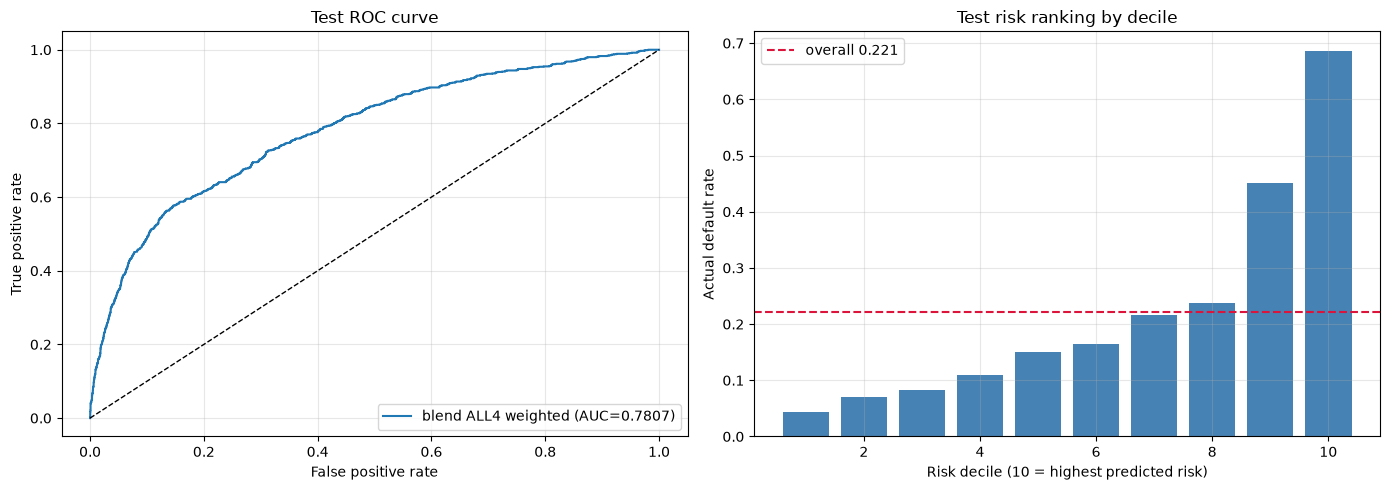

Lowest decile default rate:  0.0444
Highest decile default rate: 0.6867
Lift (highest / lowest):     15.45x


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y["test"], test_scores)
axes[0].plot(fpr, tpr, label=f"{CHAMPION} (AUC={test_metrics['roc_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("Test ROC curve")
axes[0].legend(loc="lower right")

deciles = pd.qcut(test_scores, 10, labels=False, duplicates="drop")
decile_rates = pd.DataFrame(
    {"decile": deciles, "y": y["test"].to_numpy()}
).groupby("decile")["y"].mean()
axes[1].bar(decile_rates.index + 1, decile_rates.to_numpy(), color="steelblue")
axes[1].axhline(y["test"].mean(), color="crimson", ls="--",
                label=f"overall {y['test'].mean():.3f}")
axes[1].set_xlabel("Risk decile (10 = highest predicted risk)")
axes[1].set_ylabel("Actual default rate")
axes[1].set_title("Test risk ranking by decile")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Lowest decile default rate:  {decile_rates.iloc[0]:.4f}")
print(f"Highest decile default rate: {decile_rates.iloc[-1]:.4f}")
print(f"Lift (highest / lowest):     {decile_rates.iloc[-1] / decile_rates.iloc[0]:.2f}x")

The decile chart is the clearest evidence that this works as a scorecard. Actual default rates
should rise steadily from decile 1 to decile 10, and the gap between the two ends is the
model's practical power to separate good customers from bad ones.

## 10. Fairness audit

Two measures, computed on the test split for each protected attribute.

**Disparate Impact Ratio (DIR)** compares the share of favourable outcomes in the worst-treated
group against the best-treated group, where favourable means not being flagged as a risk. The
four-fifths rule treats DIR below 0.80 as a sign of adverse impact.

**Equalized odds** compares true-positive and false-positive rates across groups. A model can
pass DIR and still be clearly less accurate for one group, which this catches.

Groups with fewer than 50 members or 10 defaults are skipped, because their rates are too noisy
to read.

In [20]:
def fairness_report(attribute: str, labels: dict | None = None) -> pd.DataFrame:
    groups = audit["test"][attribute]
    if attribute == "AGE":
        groups = pd.cut(groups, AGE_BANDS, labels=AGE_LABELS)

    positions = {value: np.where(groups.to_numpy() == value)[0]
                 for value in groups.dropna().unique()}

    rows = []
    for value, position in positions.items():
        group_y = y["test"].to_numpy()[position]
        group_pred = predicted_test[position]
        group_scores = test_scores[position]
        if len(group_y) < 50 or group_y.sum() < 10:
            continue
        tn_, fp_, fn_, tp_ = confusion_matrix(group_y, group_pred, labels=[0, 1]).ravel()
        rows.append({
            "group": labels.get(value, value) if labels else value,
            "n": len(group_y),
            "actual_default_rate": group_y.mean(),
            "favourable_rate": 1 - group_pred.mean(),
            "tpr": tp_ / (tp_ + fn_) if (tp_ + fn_) else np.nan,
            "fpr": fp_ / (fp_ + tn_) if (fp_ + tn_) else np.nan,
            "auc": roc_auc_score(group_y, group_scores),
        })

    report = pd.DataFrame(rows).set_index("group").sort_index()
    report.attrs["DIR"] = report["favourable_rate"].min() / report["favourable_rate"].max()
    report.attrs["TPR_gap"] = report["tpr"].max() - report["tpr"].min()
    report.attrs["FPR_gap"] = report["fpr"].max() - report["fpr"].min()
    return report


summary_rows = []
for attribute, labels in [("SEX", SEX_LABELS), ("AGE", None),
                          ("EDUCATION", EDUCATION_LABELS), ("MARRIAGE", MARRIAGE_LABELS)]:
    report = fairness_report(attribute, labels)
    print(f"\n=== {attribute} ===")
    print(report.round(4).to_string())
    summary_rows.append({
        "attribute": attribute,
        "disparate_impact_ratio": report.attrs["DIR"],
        "passes_four_fifths": report.attrs["DIR"] >= 0.80,
        "equalized_odds_TPR_gap": report.attrs["TPR_gap"],
        "equalized_odds_FPR_gap": report.attrs["FPR_gap"],
        "auc_spread": report["auc"].max() - report["auc"].min(),
    })

fairness_summary = pd.DataFrame(summary_rows).set_index("attribute")
print("\n\n=== FAIRNESS SUMMARY (test split) ===")
fairness_summary


=== SEX ===
           n  actual_default_rate  favourable_rate    tpr    fpr    auc
group                                                                  
female  2734               0.2004           0.7425 0.6131 0.1683 0.7992
male    1766               0.2537           0.6959 0.5893 0.2071 0.7549

=== AGE ===
          n  actual_default_rate  favourable_rate    tpr    fpr    auc
group                                                                 
21-30  1616               0.2215           0.7067 0.6480 0.1924 0.7979
31-40  1628               0.2021           0.7475 0.5775 0.1701 0.7701
41-50   908               0.2346           0.7225 0.5822 0.1842 0.7708
51-60   313               0.2812           0.7093 0.5682 0.1822 0.7876

=== EDUCATION ===
                    n  actual_default_rate  favourable_rate    tpr    fpr    auc
group                                                                           
graduate school  1580               0.2025           0.7646 0.5656 0.1516 0.775

,disparate_impact_ratio,passes_four_fifths,equalized_odds_TPR_gap,equalized_odds_FPR_gap,auc_spread
attribute,,,,,
SEX,0.9373,True,0.0239,0.0388,0.0443
AGE,0.9453,True,0.0799,0.0222,0.0278
EDUCATION,0.8879,True,0.0696,0.0786,0.0479
MARRIAGE,0.9882,True,0.0191,0.0253,0.0001


## 11. Feature importance

Permutation importance, measured on the test split against AUC. Unlike a tree's own split
counts it works for any model and does not favour high-cardinality features, so it is the
better basis for the explanations shown to users.

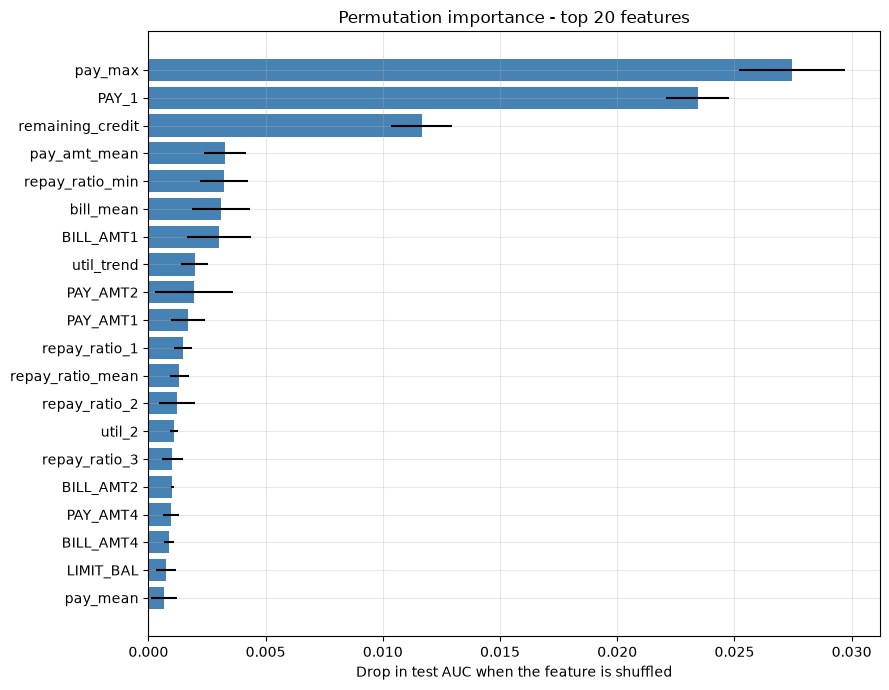

,auc_drop,std
feature,,
pay_max,0.0275,0.0023
PAY_1,0.0234,0.0013
remaining_credit,0.0117,0.0013
pay_amt_mean,0.0033,0.0009
repay_ratio_min,0.0032,0.0010
bill_mean,0.0031,0.0012
BILL_AMT1,0.0030,0.0014
util_trend,0.0020,0.0006
PAY_AMT2,0.0019,0.0017


In [21]:
importance_model = build_lgbm(SEED).fit(X_dev, y_dev)
permutation = permutation_importance(
    importance_model, X["test"], y["test"],
    scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1,
)

importance = pd.DataFrame({
    "feature": X["test"].columns,
    "auc_drop": permutation.importances_mean,
    "std": permutation.importances_std,
}).set_index("feature").sort_values("auc_drop", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
top = importance.head(20).iloc[::-1]
ax.barh(top.index, top["auc_drop"], xerr=top["std"], color="steelblue")
ax.set_xlabel("Drop in test AUC when the feature is shuffled")
ax.set_title("Permutation importance - top 20 features")
plt.tight_layout()
plt.show()

importance.head(20)

## 12. Persist artifacts

The final model, calibrator, threshold and metrics are saved to "backend/artifacts/" for the
FastAPI service to load. The metadata file records which split each number came from, which is
what the admin model-registry screen needs to report a model version honestly.

In [22]:
import joblib

final_model = build_lgbm(SEED).fit(X_dev, y_dev)

final_calibrator = IsotonicRegression(out_of_bounds="clip")
final_calibrator.fit(
    seed_average(build_lgbm, X["train"], y["train"], X["validation"]), y["validation"]
)

joblib.dump(final_model, ARTIFACTS / "model_lightgbm.joblib")
joblib.dump(final_calibrator, ARTIFACTS / "calibrator_isotonic.joblib")

metadata = {
    "dataset": "UCI Default of Credit Card Clients (Yeh & Lien, 2009)",
    "task": "behavioural scoring - probability of default next month",
    "champion_model": CHAMPION,
    "calibration_method": CALIBRATION_METHOD,
    "feature_names": list(X["train"].columns),
    "protected_attributes_excluded": PROTECTED,
    "n_features": int(X["train"].shape[1]),
    "threshold_f1_optimal": float(F1_THRESHOLD),
    "validation_metrics": {k: float(v) for k, v in validation_metrics.items()},
    "test_metrics": {k: float(v) for k, v in test_metrics.items()},
    "fairness_summary": json.loads(fairness_summary.to_json(orient="index")),
    "split_sizes": {name: int(len(X[name])) for name in X},
    "seed": SEED,
}
with open(ARTIFACTS / "model_metadata.json", "w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2)

print("Written to", ARTIFACTS)
for path in sorted(ARTIFACTS.glob("*")):
    print(f"  {path.name}  ({path.stat().st_size:,} bytes)")

Written to C:\Users\User\Documents\UNI\credit_risk_system\backend\artifacts
  calibrator_isotonic.joblib  (1,543 bytes)
  model_lightgbm.joblib  (585,350 bytes)
  model_metadata.json  (3,035 bytes)


## Summary

The cell below prints the headline numbers for the results chapter.

In [23]:
print("=" * 64)
print("CREDIT-RISK BEHAVIOURAL SCORING - FINAL RESULTS")
print("=" * 64)
print("Dataset          UCI Default of Credit Card Clients (30,000 customers)")
print("Task             probability of default next month")
print(f"Champion model   {CHAMPION}")
print(f"Features         {X['train'].shape[1]} engineered, protected attributes excluded")
print(f"Split            {len(X['train']):,} train / {len(X['validation']):,} validation "
      f"/ {len(X['test']):,} test")
print("-" * 64)
print(f"Test ROC-AUC     {test_metrics['roc_auc']:.4f}")
print(f"Test Gini        {test_metrics['gini']:.4f}")
print(f"Test KS          {test_metrics['ks']:.4f}")
print(f"Test PR-AUC      {test_metrics['pr_auc']:.4f}")
print(f"Test F1          {test_metrics['f1']:.4f}  "
      f"(precision {test_metrics['precision']:.4f}, recall {test_metrics['recall']:.4f})")
print("-" * 64)
for attribute, row in fairness_summary.iterrows():
    verdict = "PASS" if row["passes_four_fifths"] else "REVIEW"
    print(f"DIR {attribute:<10} {row['disparate_impact_ratio']:.4f}   [{verdict}]")
print("=" * 64)

CREDIT-RISK BEHAVIOURAL SCORING - FINAL RESULTS
Dataset          UCI Default of Credit Card Clients (30,000 customers)
Task             probability of default next month
Champion model   blend ALL4 weighted
Features         46 engineered, protected attributes excluded
Split            21,000 train / 4,500 validation / 4,500 test
----------------------------------------------------------------
Test ROC-AUC     0.7807
Test Gini        0.5615
Test KS          0.4306
Test PR-AUC      0.5553
Test F1          0.5364  (precision 0.4835, recall 0.6024)
----------------------------------------------------------------
DIR SEX        0.9373   [PASS]
DIR AGE        0.9453   [PASS]
DIR EDUCATION  0.8879   [PASS]
DIR MARRIAGE   0.9882   [PASS]
